In [184]:
import matplotlib.pyplot as plt
import matplotlib.ticker as tkr
import numpy as np
import pandas as pd
import math
from sklearn.cluster import KMeans
import matplotlib.ticker as ticker
from matplotlib import rc

import seaborn as sns

def custom_grouping(index):
    return index // 1000

names_latency=['submission_time', 'duration', 'direction', 'write_size', 'op3']
columns = ['submission_time', 'duration', 'write_size','direction']

## CMR - 4KB + 90-10 r/w test.

In [185]:
df_cmr = pd.read_csv('fast2026/rw_test/RWTest/4KB/90-10-LBA/CMR/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df_cmr_read = df_cmr[df_cmr['direction'] == 0].copy() # Read is 0 in fio logs
df_cmr_write = df_cmr[df_cmr['direction'] == 1].copy() # Write is 1 in fio logs

df_cmr_read['submission_time'] = round(df_cmr_read['submission_time'] - df_cmr_read.iloc[0].submission_time)
df_cmr_read['duration'] = df_cmr_read['duration']/1e6 #convert ns to ms
df_cmr_read['completion_time'] = df_cmr_read['submission_time'] + df_cmr_read['duration']

df_cmr_write['submission_time'] = round(df_cmr_write['submission_time'] - df_cmr_write.iloc[0].submission_time)
df_cmr_write['duration'] = df_cmr_write['duration']/1e6 #convert ns to ms
df_cmr_write['completion_time'] = df_cmr_write['submission_time'] + df_cmr_write['duration']

print(df_cmr_read.head())
print(df_cmr_write.head())

    submission_time  duration  direction  write_size  completion_time
1                 0  0.821707          0        4096         0.821707
15                0  0.866289          0        4096         0.866289
17                0  0.870252          0        4096         0.870252
18                0  0.870968          0        4096         0.870968
19                0  0.871973          0        4096         0.871973
   submission_time  duration  direction  write_size  completion_time
0                0  0.791872          1        4096         0.791872
2                0  0.825702          1        4096         0.825702
3                0  0.828422          1        4096         0.828422
4                0  0.834144          1        4096         0.834144
5                0  0.839163          1        4096         0.839163


In [186]:
# Step 3: Determine time range
start_time = df_cmr_write['submission_time'].min()
end_time = math.ceil(df_cmr_write['completion_time'].max())

# Pre-compute all values vectorized
df_cmr_write_vec = df_cmr_write.copy()
df_cmr_write_vec['duration'] = df_cmr_write_vec['duration'].astype(float)
df_cmr_write_vec['start'] = df_cmr_write_vec['submission_time'].astype(int)
df_cmr_write_vec['end'] = df_cmr_write_vec['start'] + np.floor(df_cmr_write_vec['duration']).astype(int)

payload = 4096  # 4KB
df_cmr_write_vec['write_rate_per_ms'] = payload / np.maximum(df_cmr_write_vec['duration'], 1.0)
df_cmr_write_vec['floor_duration'] = np.floor(df_cmr_write_vec['duration']).astype(int)
df_cmr_write_vec['residue'] = payload - df_cmr_write_vec['write_rate_per_ms'] * df_cmr_write_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_cmr_write_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)

#########################################################
#Read Calculations
#########################################################
# Step 3: Determine time range
start_time = df_cmr_read['submission_time'].min()
end_time = math.ceil(df_cmr_read['completion_time'].max())

# Pre-compute all values vectorized
df_cmr_read_vec = df_cmr_read.copy()
df_cmr_read_vec['duration'] = df_cmr_read_vec['duration'].astype(float)
df_cmr_read_vec['start'] = df_cmr_read_vec['submission_time'].astype(int)
df_cmr_read_vec['end'] = df_cmr_read_vec['start'] + np.floor(df_cmr_read_vec['duration']).astype(int)

payload = 4096  # 4KB
df_cmr_read_vec['write_rate_per_ms'] = payload / np.maximum(df_cmr_read_vec['duration'], 1.0)
df_cmr_read_vec['floor_duration'] = np.floor(df_cmr_read_vec['duration']).astype(int)
df_cmr_read_vec['residue'] = payload - df_cmr_read_vec['write_rate_per_ms'] * df_cmr_read_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_read_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_cmr_read_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_read_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_read_array):
        data_read_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_read_ms_vec = pd.DataFrame({
    'data_read_bytes': data_read_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_read_ms_vec['data_read_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_read_ms_vec = data_read_ms_vec.loc[:last_non_zero_index]

data_read_ms_vec.reset_index(drop=True, inplace=True)

In [187]:
#########################################################
#Write calculations
###########################################################
chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_cmr_write_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_cmr_write_grouped_vec.reset_index(inplace=True)
df_cmr_write_grouped_vec['cumulative_gb'] = df_cmr_write_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_cmr_write_grouped_vec['data_written_bytes'] = df_cmr_write_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_cmr_write_grouped_vec.describe())
print(df_cmr_write_grouped_vec.info())

#Average write bandwidth
cmr_average_write_bandwidth = df_cmr_write_grouped_vec['data_written_bytes'].mean()
cmr_avg_write_bw_str = f"{cmr_average_write_bandwidth:.2f} MB/s"
print(f"Average Write Bandwidth: {cmr_avg_write_bw_str}")

#########################################################
#Read calculations
###########################################################
chunk_size = 10000
results = []
for i in range(0, len(data_read_ms_vec), chunk_size):
    chunk = data_read_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)
df_cmr_read_grouped_vec = pd.concat(results)
# Reset the index to make it a regular column
df_cmr_read_grouped_vec.reset_index(inplace=True)
df_cmr_read_grouped_vec['cumulative_gb'] = df_cmr_read_grouped_vec['data_read_bytes'].cumsum() / (1024 ** 3)
df_cmr_read_grouped_vec['data_read_bytes'] = df_cmr_read_grouped_vec['data_read_bytes'] / (1024 ** 2) 
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_cmr_read_grouped_vec.describe())
print(df_cmr_read_grouped_vec.info())

#Average read bandwidth
cmr_average_read_bandwidth = df_cmr_read_grouped_vec['data_read_bytes'].mean()
cmr_avg_read_bw_str = f"{cmr_average_read_bandwidth:.2f} MB/s"
print(f"Average Read Bandwidth: {cmr_average_read_bandwidth:.2f} MB/s")

#Completion time -- max index in main dataframe
print(f"Write Completion time (s): {df_cmr_write_grouped_vec['index'].max()}")
print(f"Read Completion time (s): {df_cmr_read_grouped_vec['index'].max()}")
cmr_completion_time = max(df_cmr_write_grouped_vec['index'].max(), df_cmr_read_grouped_vec['index'].max())
print(f"Overall Completion time (min): {cmr_completion_time/60}")

            index  data_written_bytes  cumulative_gb
count  609.000000          609.000000     609.000000
mean   304.000000            3.363846       1.039451
std    175.947435            0.482630       0.569335
min      0.000000            1.210475       0.004252
25%    152.000000            3.063926       0.556537
50%    304.000000            3.374924       1.048265
75%    456.000000            3.644086       1.536759
max    608.000000            6.348941       2.000568
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               609 non-null    int64  
 1   data_written_bytes  609 non-null    float64
 2   cumulative_gb       609 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 14.4 KB
None
Average Write Bandwidth: 3.36 MB/s
            index  data_read_bytes  cumulative_gb
count  610.000000       610.00000

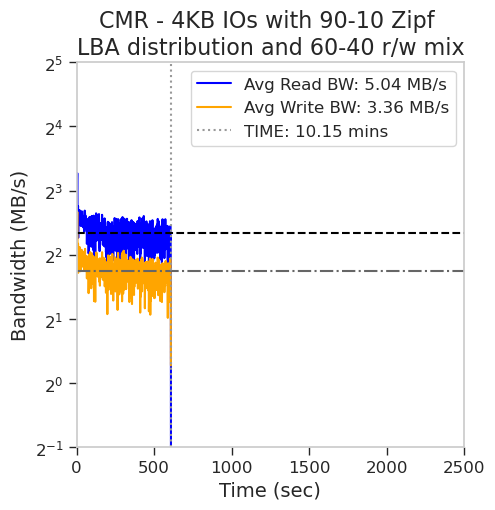

In [217]:
plt.figure(figsize=(5, 5))
plt.grid(False)
sns.set_theme(style="whitegrid")

ax1 = sns.lineplot(
    x='index', y='data_read_bytes', 
    data=df_cmr_read_grouped_vec, 
    label='Avg Read BW: '+cmr_avg_read_bw_str, 
    color='blue'
)
ax2 = sns.lineplot(
    x='index', y='data_written_bytes', 
    data=df_cmr_write_grouped_vec, 
    label='Avg Write BW: '+cmr_avg_write_bw_str, 
    color='orange'
)

ax1.set_xlabel('Time (sec)', fontsize=14)
ax1.set_ylabel('Bandwidth (MB/s)', fontsize=14)

# Add horizontal reference lines
plt.axhline(y=cmr_average_read_bandwidth, color='#000000', linestyle='--')
plt.axhline(y=cmr_average_write_bandwidth, color='#666666', linestyle='-.')
plt.axvline(x=cmr_completion_time, color='#999999', linestyle=':', label='TIME: '+str(cmr_completion_time/60)+' mins')

# Tick parameters with tick marks enabled
ax1.tick_params(axis='x', labelsize=12, direction='out', length=6, width=1, bottom=True, top=False)
ax1.tick_params(axis='y', labelsize=12, direction='out', length=6, width=1, left=True, right=False)

ax1.set_xlim(0, 2500)
ax1.set_xticks(ticks=np.arange(0, 2501, 500))
ax1.legend(fontsize=12)

# Log base-2 formatting
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

common_yticks = [2**i for i in range(-1, 5, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-1, 5, 2)])

lowest_power_of_2 = 2 ** -1
ax1.set_ylim(lowest_power_of_2 , 2**5)
ax1.set_yscale('log', base=2)
ax1.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))

ax1.set_title(r'CMR - 4KB IOs with 90-10 Zipf ' '\n' r'LBA distribution and 60-40 r/w mix', fontsize=16)
plt.savefig('fig/fast2026/read_write_test/cmr_4kb_90-10_rw_test.pdf', dpi=300, bbox_inches='tight')
plt.show()

## DM-Hybrid on DM-SMR - 4KB + 90-10 r/w test.

In [189]:
df_dmhybrid = pd.read_csv('fast2026/rw_test/RWTest/4KB/90-10-LBA/DM-SMR/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df_dmhybrid_read = df_dmhybrid[df_dmhybrid['direction'] == 0].copy() # Read is 0 in fio logs
df_dmhybrid_write = df_dmhybrid[df_dmhybrid['direction'] == 1].copy() # Write is 1 in fio logs

df_dmhybrid_read['submission_time'] = round(df_dmhybrid_read['submission_time'] - df_dmhybrid_read.iloc[0].submission_time)
df_dmhybrid_read['duration'] = df_dmhybrid_read['duration']/1e6 #convert ns to ms
df_dmhybrid_read['completion_time'] = df_dmhybrid_read['submission_time'] + df_dmhybrid_read['duration']

df_dmhybrid_write['submission_time'] = round(df_dmhybrid_write['submission_time'] - df_dmhybrid_write.iloc[0].submission_time)
df_dmhybrid_write['duration'] = df_dmhybrid_write['duration']/1e6 #convert ns to ms
df_dmhybrid_write['completion_time'] = df_dmhybrid_write['submission_time'] + df_dmhybrid_write['duration']

print(df_dmhybrid_read.head())
print(df_dmhybrid_write.head())

   submission_time  duration  direction  write_size  completion_time
0                0  0.870277          0        4096         0.870277
1                0  0.946171          0        4096         0.946171
2                1  0.960857          0        4096         1.960857
3                1  0.969960          0        4096         1.969960
4                1  0.977826          0        4096         1.977826
    submission_time  duration  direction  write_size  completion_time
6                 0  0.900865          1        4096         0.900865
7                 0  0.926786          1        4096         0.926786
8                 0  1.025589          1        4096         1.025589
9                 0  1.034698          1        4096         1.034698
10                0  1.041792          1        4096         1.041792


In [190]:
# Step 3: Determine time range
start_time = df_dmhybrid_write['submission_time'].min()
end_time = math.ceil(df_dmhybrid_write['completion_time'].max())

# Pre-compute all values vectorized
df_dmhybrid_write = df_dmhybrid_write.copy()
df_dmhybrid_write['duration'] = df_dmhybrid_write['duration'].astype(float)
df_dmhybrid_write['start'] = df_dmhybrid_write['submission_time'].astype(int)
df_dmhybrid_write['end'] = df_dmhybrid_write['start'] + np.floor(df_dmhybrid_write['duration']).astype(int)

payload = 4096  # 4KB
df_dmhybrid_write['write_rate_per_ms'] = payload / np.maximum(df_dmhybrid_write['duration'], 1.0)
df_dmhybrid_write['floor_duration'] = np.floor(df_dmhybrid_write['duration']).astype(int)
df_dmhybrid_write['residue'] = payload - df_dmhybrid_write['write_rate_per_ms'] * df_dmhybrid_write['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_dmhybrid_write.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)

#########################################################
#Read Calculations
#########################################################
# Step 3: Determine time range
start_time = df_dmhybrid_read['submission_time'].min()
end_time = math.ceil(df_dmhybrid_read['completion_time'].max())

# Pre-compute all values vectorized
df_dmhybrid_read_vec = df_dmhybrid_read.copy()
df_dmhybrid_read_vec['duration'] = df_dmhybrid_read_vec['duration'].astype(float)
df_dmhybrid_read_vec['start'] = df_dmhybrid_read_vec['submission_time'].astype(int)
df_dmhybrid_read_vec['end'] = df_dmhybrid_read_vec['start'] + np.floor(df_dmhybrid_read_vec['duration']).astype(int)

payload = 4096  # 4KB
df_dmhybrid_read_vec['write_rate_per_ms'] = payload / np.maximum(df_dmhybrid_read_vec['duration'], 1.0)
df_dmhybrid_read_vec['floor_duration'] = np.floor(df_dmhybrid_read_vec['duration']).astype(int)
df_dmhybrid_read_vec['residue'] = payload - df_dmhybrid_read_vec['write_rate_per_ms'] * df_dmhybrid_read_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_read_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_dmhybrid_read_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_read_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_read_array):
        data_read_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_read_ms_vec = pd.DataFrame({
    'data_read_bytes': data_read_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_read_ms_vec['data_read_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_read_ms_vec = data_read_ms_vec.loc[:last_non_zero_index]

data_read_ms_vec.reset_index(drop=True, inplace=True)

In [191]:
#########################################################
#Write calculations
###########################################################
chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_dmhybrid_write_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_dmhybrid_write_grouped_vec.reset_index(inplace=True)
df_dmhybrid_write_grouped_vec['cumulative_gb'] = df_dmhybrid_write_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_dmhybrid_write_grouped_vec['data_written_bytes'] = df_dmhybrid_write_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_dmhybrid_write_grouped_vec.describe())
print(df_dmhybrid_write_grouped_vec.info())

#Average write bandwidth
dmhybrid_average_write_bandwidth = df_dmhybrid_write_grouped_vec['data_written_bytes'].mean()
dmhybrid_avg_write_bw_str = f"{dmhybrid_average_write_bandwidth:.2f} MB/s"
print(f"Average Write Bandwidth: {dmhybrid_avg_write_bw_str}")

#########################################################
#Read calculations
###########################################################
chunk_size = 10000
results = []
for i in range(0, len(data_read_ms_vec), chunk_size):
    chunk = data_read_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)
df_dmhybrid_read_grouped_vec = pd.concat(results)
# Reset the index to make it a regular column
df_dmhybrid_read_grouped_vec.reset_index(inplace=True)
df_dmhybrid_read_grouped_vec['cumulative_gb'] = df_dmhybrid_read_grouped_vec['data_read_bytes'].cumsum() / (1024 ** 3)
df_dmhybrid_read_grouped_vec['data_read_bytes'] = df_dmhybrid_read_grouped_vec['data_read_bytes'] / (1024 ** 2) 
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_dmhybrid_read_grouped_vec.describe())
print(df_dmhybrid_read_grouped_vec.info())

#Average read bandwidth
dmhybrid_average_read_bandwidth = df_dmhybrid_read_grouped_vec['data_read_bytes'].mean()
dmhybrid_avg_read_bw_str = f"{dmhybrid_average_read_bandwidth:.2f} MB/s"
print(f"Average Read Bandwidth: {dmhybrid_avg_read_bw_str}")

#Completion time -- max index in main dataframe
print(f"Write Completion time (s): {df_dmhybrid_write_grouped_vec['index'].max()}")
print(f"Read Completion time (s): {df_dmhybrid_read_grouped_vec['index'].max()}")
dmhybrid_completion_time = max(df_dmhybrid_write_grouped_vec['index'].max(), df_dmhybrid_read_grouped_vec['index'].max())
print(f"Overall Completion time (min): {dmhybrid_completion_time/60}")

             index  data_written_bytes  cumulative_gb
count  1125.000000         1125.000000    1125.000000
mean    562.000000            1.820962       1.023226
std     324.903832            0.188936       0.578258
min       0.000000            0.117187       0.000938
25%     281.000000            1.712684       0.527452
50%     562.000000            1.827371       1.039729
75%     843.000000            1.946517       1.523659
max    1124.000000            2.268413       2.000568
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               1125 non-null   int64  
 1   data_written_bytes  1125 non-null   float64
 2   cumulative_gb       1125 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 26.5 KB
None
Average Write Bandwidth: 1.82 MB/s
             index  data_read_bytes  cumulative_gb
count  1126.000000   

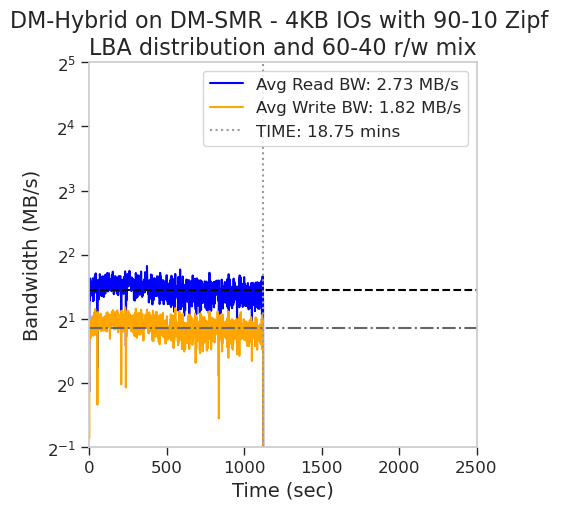

In [218]:
#Plotting
plt.figure(figsize=(5, 5))
plt.grid(False)
sns.set_theme(style="whitegrid")

ax1 = sns.lineplot(
    x='index', y='data_read_bytes', 
    data=df_dmhybrid_read_grouped_vec, 
    label='Avg Read BW: '+dmhybrid_avg_read_bw_str, 
    color='blue'
)
ax2 = sns.lineplot(
    x='index', y='data_written_bytes', 
    data=df_dmhybrid_write_grouped_vec, 
    label='Avg Write BW: '+dmhybrid_avg_write_bw_str, 
    color='orange'
)

ax1.set_xlabel('Time (sec)', fontsize=14)
ax1.set_ylabel('Bandwidth (MB/s)', fontsize=14)

# Add horizontal reference lines
plt.axhline(y=dmhybrid_average_read_bandwidth, color='#000000', linestyle='--')
plt.axhline(y=dmhybrid_average_write_bandwidth, color='#666666', linestyle='-.')
plt.axvline(x=dmhybrid_completion_time, color='#999999', linestyle=':', label='TIME: '+str(dmhybrid_completion_time/60)+' mins')

# Tick parameters with tick marks enabled
ax1.tick_params(axis='x', labelsize=12, direction='out', length=6, width=1, bottom=True, top=False)
ax1.tick_params(axis='y', labelsize=12, direction='out', length=6, width=1, left=True, right=False)

ax1.set_xlim(0, 2500)
ax1.set_xticks(ticks=np.arange(0, 2501, 500))
ax1.legend(fontsize=12)

# Log base-2 formatting
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

common_yticks = [2**i for i in range(-1, 5, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-1, 5, 2)])

lowest_power_of_2 = 2 ** -1
ax1.set_ylim(lowest_power_of_2 , 2**5)
ax1.set_yscale('log', base=2)
ax1.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))

ax1.set_title(
    r'DM-Hybrid on DM-SMR - 4KB IOs with 90-10 Zipf ' '\n' 
    r'LBA distribution and 60-40 r/w mix', 
    fontsize=16
)

plt.savefig('fig/fast2026/read_write_test/dmhybrid_4kb_90-10_rw_test.pdf', dpi=300, bbox_inches='tight')
plt.show()


## DM-Hybrid on HA-SMR - 4KB + 60-40 r/w test.

In [212]:
df_dm_hasmr = pd.read_csv('fast2026/rw_test/RWTest/4KB/90-10-LBA/HA-SMR/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df_dm_hasmr_read = df_dm_hasmr[df_dm_hasmr['direction'] == 0].copy() # Read is 0 in fio logs
df_dm_hasmr_write = df_dm_hasmr[df_dm_hasmr['direction'] == 1].copy() # Write is 1 in fio logs

df_dm_hasmr_read['submission_time'] = round(df_dm_hasmr_read['submission_time'] - df_dm_hasmr_read.iloc[0].submission_time)
df_dm_hasmr_read['duration'] = df_dm_hasmr_read['duration']/1e6 #convert ns to ms
df_dm_hasmr_read['completion_time'] = df_dm_hasmr_read['submission_time'] + df_dm_hasmr_read['duration']

df_dm_hasmr_write['submission_time'] = round(df_dm_hasmr_write['submission_time'] - df_dm_hasmr_write.iloc[0].submission_time)
df_dm_hasmr_write['duration'] = df_dm_hasmr_write['duration']/1e6 #convert ns to ms
df_dm_hasmr_write['completion_time'] = df_dm_hasmr_write['submission_time'] + df_dm_hasmr_write['duration']

print(df_dm_hasmr_read.head())
print(df_dm_hasmr_write.head())

   submission_time  duration  direction  write_size  completion_time
0                0  0.270800          0        4096         0.270800
1                0  0.292594          0        4096         0.292594
2                0  0.294356          0        4096         0.294356
3                0  0.295121          0        4096         0.295121
4                0  0.295947          0        4096         0.295947
    submission_time  duration  direction  write_size  completion_time
10                0  0.314776          1        4096         0.314776
11                0  0.325225          1        4096         0.325225
12                0  0.322603          1        4096         0.322603
13                0  0.330183          1        4096         0.330183
14                0  0.332926          1        4096         0.332926


In [213]:
# Step 3: Determine time range
start_time = df_dm_hasmr_write['submission_time'].min()
end_time = math.ceil(df_dm_hasmr_write['completion_time'].max())

# Pre-compute all values vectorized
df_dm_hasmr_write = df_dm_hasmr_write.copy()
df_dm_hasmr_write['duration'] = df_dm_hasmr_write['duration'].astype(float)
df_dm_hasmr_write['start'] = df_dm_hasmr_write['submission_time'].astype(int)
df_dm_hasmr_write['end'] = df_dm_hasmr_write['start'] + np.floor(df_dm_hasmr_write['duration']).astype(int)

payload = 4096  # 4KB
df_dm_hasmr_write['write_rate_per_ms'] = payload / np.maximum(df_dm_hasmr_write['duration'], 1.0)
df_dm_hasmr_write['floor_duration'] = np.floor(df_dm_hasmr_write['duration']).astype(int)
df_dm_hasmr_write['residue'] = payload - df_dm_hasmr_write['write_rate_per_ms'] * df_dm_hasmr_write['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_dm_hasmr_write.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)

#########################################################
#Read Calculations
#########################################################
# Step 3: Determine time range
start_time = df_dm_hasmr_read['submission_time'].min()
end_time = math.ceil(df_dm_hasmr_read['completion_time'].max())

# Pre-compute all values vectorized
df_dm_hasmr_read_vec = df_dm_hasmr_read.copy()
df_dm_hasmr_read_vec['duration'] = df_dm_hasmr_read_vec['duration'].astype(float)
df_dm_hasmr_read_vec['start'] = df_dm_hasmr_read_vec['submission_time'].astype(int)
df_dm_hasmr_read_vec['end'] = df_dm_hasmr_read_vec['start'] + np.floor(df_dm_hasmr_read_vec['duration']).astype(int)

payload = 4096  # 4KB
df_dm_hasmr_read_vec['write_rate_per_ms'] = payload / np.maximum(df_dm_hasmr_read_vec['duration'], 1.0)
df_dm_hasmr_read_vec['floor_duration'] = np.floor(df_dm_hasmr_read_vec['duration']).astype(int)
df_dm_hasmr_read_vec['residue'] = payload - df_dm_hasmr_read_vec['write_rate_per_ms'] * df_dm_hasmr_read_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_read_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_dm_hasmr_read_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_read_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_read_array):
        data_read_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_read_ms_vec = pd.DataFrame({
    'data_read_bytes': data_read_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_read_ms_vec['data_read_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_read_ms_vec = data_read_ms_vec.loc[:last_non_zero_index]

data_read_ms_vec.reset_index(drop=True, inplace=True)

In [214]:
#########################################################
#Write calculations
###########################################################
chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_dm_hasmr_write_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_dm_hasmr_write_grouped_vec.reset_index(inplace=True)
df_dm_hasmr_write_grouped_vec['cumulative_gb'] = df_dm_hasmr_write_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_dm_hasmr_write_grouped_vec['data_written_bytes'] = df_dm_hasmr_write_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_dm_hasmr_write_grouped_vec.describe())
print(df_dm_hasmr_write_grouped_vec.info())

#Average write bandwidth
dm_hasmr_average_write_bandwidth = df_dm_hasmr_write_grouped_vec['data_written_bytes'].mean()
print(f"Average Write Bandwidth: {dm_hasmr_average_write_bandwidth:.2f} MB/s")
dm_hasmr_avg_write_bw_str = f"{dm_hasmr_average_write_bandwidth:.2f} MB/s"

#########################################################
#Read calculations
###########################################################
chunk_size = 10000
results = []
for i in range(0, len(data_read_ms_vec), chunk_size):
    chunk = data_read_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)
df_dm_hasmr_read_grouped_vec = pd.concat(results)
# Reset the index to make it a regular column
df_dm_hasmr_read_grouped_vec.reset_index(inplace=True)
df_dm_hasmr_read_grouped_vec['cumulative_gb'] = df_dm_hasmr_read_grouped_vec['data_read_bytes'].cumsum() / (1024 ** 3)
df_dm_hasmr_read_grouped_vec['data_read_bytes'] = df_dm_hasmr_read_grouped_vec['data_read_bytes'] / (1024 ** 2) 
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_dm_hasmr_read_grouped_vec.describe())
print(df_dm_hasmr_read_grouped_vec.info())

#Average read bandwidth
dm_hasmr_average_read_bandwidth = df_dm_hasmr_read_grouped_vec['data_read_bytes'].mean()
print(f"Average Read Bandwidth: {dm_hasmr_average_read_bandwidth:.2f} MB/s")
dm_hasmr_avg_read_bw_str = f"{dm_hasmr_average_read_bandwidth:.2f} MB/s"

#Completion time -- max index in main dataframe
print(f"Write Completion time (s): {df_dm_hasmr_write_grouped_vec['index'].max()}")
print(f"Read Completion time (s): {df_dm_hasmr_read_grouped_vec['index'].max()}")
dm_hasmr_completion_time = max(df_dm_hasmr_write_grouped_vec['index'].max(), df_dm_hasmr_read_grouped_vec['index'].max())
print(f"Overall Completion time (min): {dm_hasmr_completion_time/60}")

             index  data_written_bytes  cumulative_gb
count  2375.000000         2375.000000    2375.000000
mean   1187.000000            0.862561       1.006749
std     685.747767            0.095409       0.575274
min       0.000000            0.001472       0.002100
25%     593.500000            0.809698       0.510416
50%    1187.000000            0.858508       1.006862
75%    1780.500000            0.913579       1.503240
max    2374.000000            2.150051       2.000568
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2375 entries, 0 to 2374
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               2375 non-null   int64  
 1   data_written_bytes  2375 non-null   float64
 2   cumulative_gb       2375 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 55.8 KB
None
Average Write Bandwidth: 0.86 MB/s
             index  data_read_bytes  cumulative_gb
count  2375.000000   

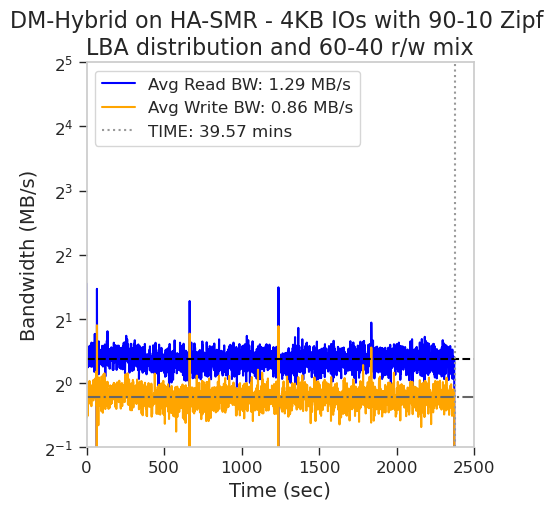

In [219]:
plt.figure(figsize=(5, 5))
plt.grid(False)
sns.set_theme(style="whitegrid")

ax1 = sns.lineplot(
    x='index', y='data_read_bytes', 
    data=df_dm_hasmr_read_grouped_vec, 
    label='Avg Read BW: '+dm_hasmr_avg_read_bw_str, 
    color='blue'
)
ax2 = sns.lineplot(
    x='index', y='data_written_bytes', 
    data=df_dm_hasmr_write_grouped_vec, 
    label='Avg Write BW: '+dm_hasmr_avg_write_bw_str, 
    color='orange'
)

ax1.set_xlabel('Time (sec)', fontsize=14)
ax1.set_ylabel('Bandwidth (MB/s)', fontsize=14)

# Add horizontal reference lines
plt.axhline(y=dm_hasmr_average_read_bandwidth, color='#000000', linestyle='--')
plt.axhline(y=dm_hasmr_average_write_bandwidth, color='#666666', linestyle='-.')
plt.axvline(x=dm_hasmr_completion_time, color='#999999', linestyle=':', label='TIME: '+str(round(dm_hasmr_completion_time/60,2))+' mins')

# Tick parameters with tick marks enabled
ax1.tick_params(axis='x', labelsize=12, direction='out', length=6, width=1, bottom=True, top=False)
ax1.tick_params(axis='y', labelsize=12, direction='out', length=6, width=1, left=True, right=False)

ax1.set_xlim(0, 2500)
ax1.set_xticks(ticks=np.arange(0, 2501, 500))
ax1.legend(fontsize=12)

# Log base-2 formatting
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

common_yticks = [2**i for i in range(-1, 5, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-1, 5, 2)])

lowest_power_of_2 = 2 ** -1
ax1.set_ylim(lowest_power_of_2 , 2**5)
ax1.set_yscale('log', base=2)
ax1.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))

ax1.set_title(r'DM-Hybrid on HA-SMR - 4KB IOs with 90-10 Zipf ' '\n' r'LBA distribution and 60-40 r/w mix', fontsize=16)

plt.savefig('fig/fast2026/read_write_test/dmhybrid_hasmr_4kb_90-10_rw_test.pdf', dpi=300, bbox_inches='tight')
plt.show()

## HM-Hybrid on HA-SMR - 4KB IOs with 90-10 r/w test. Zones are 90% full.

In [197]:
df_hm_hasmr = pd.read_csv('fast2026/rw_test/RWTest/4KB/90-10-LBA/HM-Hybrid/90Util/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df_hm_hasmr_read = df_hm_hasmr[df_hm_hasmr['direction'] == 0].copy() # Read is 0 in fio logs
df_hm_hasmr_write = df_hm_hasmr[df_hm_hasmr['direction'] == 1].copy() # Write is 1 in fio logs

df_hm_hasmr_read['submission_time'] = round(df_hm_hasmr_read['submission_time'] - df_hm_hasmr_read.iloc[0].submission_time)
df_hm_hasmr_read['duration'] = df_hm_hasmr_read['duration']/1e6 #convert ns to ms
df_hm_hasmr_read['completion_time'] = df_hm_hasmr_read['submission_time'] + df_hm_hasmr_read['duration']

df_hm_hasmr_write['submission_time'] = round(df_hm_hasmr_write['submission_time'] - df_hm_hasmr_write.iloc[0].submission_time)
df_hm_hasmr_write['duration'] = df_hm_hasmr_write['duration']/1e6 #convert ns to ms
df_hm_hasmr_write['completion_time'] = df_hm_hasmr_write['submission_time'] + df_hm_hasmr_write['duration']

print(df_hm_hasmr_read.head())
print(df_hm_hasmr_write.head())

   submission_time  duration  direction  write_size  completion_time
0                0  0.168813          0        4096         0.168813
1                0  0.180926          0        4096         0.180926
2                0  0.069747          0        4096         0.069747
3                0  0.903225          0        4096         0.903225
4                0  0.941306          0        4096         0.941306
    submission_time  duration  direction  write_size  completion_time
27                0  0.305079          1        4096         0.305079
28                0  0.248007          1        4096         0.248007
29                0  0.207378          1        4096         0.207378
30                0  0.184949          1        4096         0.184949
31                0  0.158747          1        4096         0.158747


In [198]:
# Step 3: Determine time range
start_time = df_hm_hasmr_write['submission_time'].min()
end_time = math.ceil(df_hm_hasmr_write['completion_time'].max())

# Pre-compute all values vectorized
df_hm_hasmr_write_vec = df_hm_hasmr_write.copy()
df_hm_hasmr_write_vec['duration'] = df_hm_hasmr_write_vec['duration'].astype(float)
df_hm_hasmr_write_vec['start'] = df_hm_hasmr_write_vec['submission_time'].astype(int)
df_hm_hasmr_write_vec['end'] = df_hm_hasmr_write_vec['start'] + np.floor(df_hm_hasmr_write_vec['duration']).astype(int)

payload = 4096  # 4KB
df_hm_hasmr_write_vec['write_rate_per_ms'] = payload / np.maximum(df_hm_hasmr_write_vec['duration'], 1.0)
df_hm_hasmr_write_vec['floor_duration'] = np.floor(df_hm_hasmr_write_vec['duration']).astype(int)
df_hm_hasmr_write_vec['residue'] = payload - df_hm_hasmr_write_vec['write_rate_per_ms'] * df_hm_hasmr_write_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_hm_hasmr_write_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)

#########################################################
#Read Calculations
#########################################################
# Step 3: Determine time range
start_time = df_hm_hasmr_read['submission_time'].min()
end_time = math.ceil(df_hm_hasmr_read['completion_time'].max())

# Pre-compute all values vectorized
df_hm_hasmr_read_vec = df_hm_hasmr_read.copy()
df_hm_hasmr_read_vec['duration'] = df_hm_hasmr_read_vec['duration'].astype(float)
df_hm_hasmr_read_vec['start'] = df_hm_hasmr_read_vec['submission_time'].astype(int)
df_hm_hasmr_read_vec['end'] = df_hm_hasmr_read_vec['start'] + np.floor(df_hm_hasmr_read_vec['duration']).astype(int)

payload = 4096  # 4KB
df_hm_hasmr_read_vec['write_rate_per_ms'] = payload / np.maximum(df_hm_hasmr_read_vec['duration'], 1.0)
df_hm_hasmr_read_vec['floor_duration'] = np.floor(df_hm_hasmr_read_vec['duration']).astype(int)
df_hm_hasmr_read_vec['residue'] = payload - df_hm_hasmr_read_vec['write_rate_per_ms'] * df_hm_hasmr_read_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_read_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_hm_hasmr_read_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_read_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_read_array):
        data_read_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_read_ms_vec = pd.DataFrame({
    'data_read_bytes': data_read_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_read_ms_vec['data_read_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_read_ms_vec = data_read_ms_vec.loc[:last_non_zero_index]

data_read_ms_vec.reset_index(drop=True, inplace=True)

In [199]:
#########################################################
#Write calculations
###########################################################
chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_hm_hasmr_write_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_hm_hasmr_write_grouped_vec.reset_index(inplace=True)
df_hm_hasmr_write_grouped_vec['cumulative_gb'] = df_hm_hasmr_write_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_hm_hasmr_write_grouped_vec['data_written_bytes'] = df_hm_hasmr_write_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_hm_hasmr_write_grouped_vec.describe())
print(df_hm_hasmr_write_grouped_vec.info())
#Average write bandwidth
hm_hasmr_avg_write_bandwidth = df_hm_hasmr_write_grouped_vec['data_written_bytes'].mean()
print(f"Average Write Bandwidth: {hm_hasmr_avg_write_bandwidth:.2f} MB/s")
hm_hasmr_avg_write_bw_str = f"{hm_hasmr_avg_write_bandwidth:.2f} MB/s"

#########################################################
#Read calculations
###########################################################
chunk_size = 10000
results = []
for i in range(0, len(data_read_ms_vec), chunk_size):
    chunk = data_read_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)
df_hm_hasmr_read_grouped_vec = pd.concat(results)
# Reset the index to make it a regular column
df_hm_hasmr_read_grouped_vec.reset_index(inplace=True)
df_hm_hasmr_read_grouped_vec['cumulative_gb'] = df_hm_hasmr_read_grouped_vec['data_read_bytes'].cumsum() / (1024 ** 3)
df_hm_hasmr_read_grouped_vec['data_read_bytes'] = df_hm_hasmr_read_grouped_vec['data_read_bytes'] / (1024 ** 2) 
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_hm_hasmr_read_grouped_vec.describe())
print(df_hm_hasmr_read_grouped_vec.info())
#Average read bandwidth
hm_hasmr_avg_read_bandwidth = df_hm_hasmr_read_grouped_vec['data_read_bytes'].mean()
print(f"Average Read Bandwidth: {hm_hasmr_avg_read_bandwidth:.2f} MB/s")
hm_hasmr_avg_read_bw_str = f"{hm_hasmr_avg_read_bandwidth:.2f} MB/s"

#Completion time -- max index in main dataframe
print(f"Write Completion time (s): {df_hm_hasmr_write_grouped_vec['index'].max()}")
print(f"Read Completion time (s): {df_hm_hasmr_read_grouped_vec['index'].max()}")
hm_hasmr_completion_time = max(df_hm_hasmr_write_grouped_vec['index'].max(), df_hm_hasmr_read_grouped_vec['index'].max())
print(f"Overall Completion time (min): {hm_hasmr_completion_time/60}")

            index  data_written_bytes  cumulative_gb
count  832.000000          832.000000     832.000000
mean   415.500000            2.462238       1.015793
std    240.322006            0.555642       0.572399
min      0.000000            0.089618       0.002929
25%    207.750000            2.187989       0.523023
50%    415.500000            2.386269       1.011469
75%    623.250000            2.622258       1.522130
max    831.000000            6.831779       2.000568
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 832 entries, 0 to 831
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               832 non-null    int64  
 1   data_written_bytes  832 non-null    float64
 2   cumulative_gb       832 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 19.6 KB
None
Average Write Bandwidth: 2.46 MB/s
            index  data_read_bytes  cumulative_gb
count  832.000000       832.00000

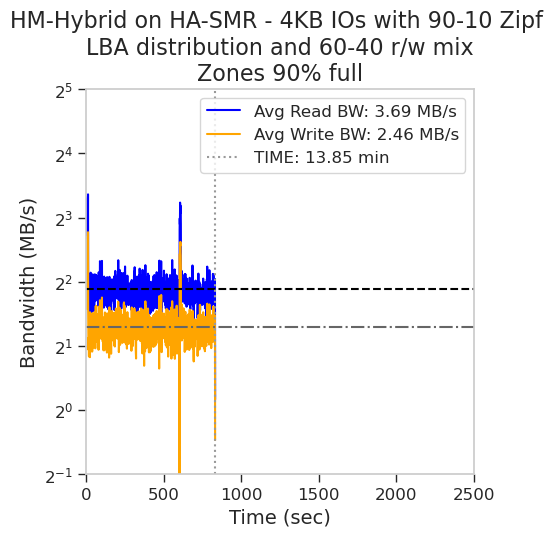

In [200]:
plt.figure(figsize=(5, 5))
plt.grid(False)
sns.set_theme(style="whitegrid")

ax1 = sns.lineplot(
    x='index', y='data_read_bytes', 
    data=df_hm_hasmr_read_grouped_vec, 
    label='Avg Read BW: '+hm_hasmr_avg_read_bw_str, 
    color='blue'
)
ax2 = sns.lineplot(
    x='index', y='data_written_bytes', 
    data=df_hm_hasmr_write_grouped_vec, 
    label='Avg Write BW: '+hm_hasmr_avg_write_bw_str, 
    color='orange'
)

ax1.set_xlabel('Time (sec)', fontsize=14)
ax1.set_ylabel('Bandwidth (MB/s)', fontsize=14)

# Add horizontal reference lines
plt.axhline(y=hm_hasmr_avg_read_bandwidth, color='#000000', linestyle='--')
plt.axhline(y=hm_hasmr_avg_write_bandwidth, color='#666666', linestyle='-.')
plt.axvline(x=hm_hasmr_completion_time, color='#999999', linestyle=':', label='TIME: '+str(hm_hasmr_completion_time/60)+' min')

# Tick parameters with tick marks enabled
ax1.tick_params(axis='x', labelsize=12, direction='out', length=6, width=1, bottom=True, top=False)
ax1.tick_params(axis='y', labelsize=12, direction='out', length=6, width=1, left=True, right=False)

ax1.set_xlim(0, 2500)
ax1.set_xticks(ticks=np.arange(0, 2501, 500))
ax1.legend(fontsize=12)

# Log base-2 formatting
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

common_yticks = [2**i for i in range(-1, 5, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-1, 5, 2)])

lowest_power_of_2 = 2 ** -1
ax1.set_ylim(lowest_power_of_2 , 2**5)
ax1.set_yscale('log', base=2)
ax1.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
ax1.set_title(r'HM-Hybrid on HA-SMR - 4KB IOs with 90-10 Zipf ' '\n' r'LBA distribution and 60-40 r/w mix' '\n' 'Zones 90% full', fontsize=16)
plt.savefig('fig/fast2026/read_write_test/hmhybrid_hasmr_4kb_90-10_rw_test.pdf', dpi=300, bbox_inches='tight')
plt.show()

## HM-Hybrid on HA-SMR - 4KB IOs with 90-10 r/w test. Zones are empty.

In [227]:
df_hm_hasmr_empty = pd.read_csv('fast2026/rw_test/RWTest/4KB/90-10-LBA/HM-Hybrid/empty/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df_hm_hasmr_empty_read = df_hm_hasmr_empty[df_hm_hasmr_empty['direction'] == 0].copy() # Read is 0 in fio logs
df_hm_hasmr_empty_write = df_hm_hasmr_empty[df_hm_hasmr_empty['direction'] == 1].copy() # Write is 1 in fio logs

df_hm_hasmr_empty_read['submission_time'] = round(df_hm_hasmr_empty_read['submission_time'] - df_hm_hasmr_empty_read.iloc[0].submission_time)
df_hm_hasmr_empty_read['duration'] = df_hm_hasmr_empty_read['duration']/1e6 #convert ns to ms
df_hm_hasmr_empty_read['completion_time'] = df_hm_hasmr_empty_read['submission_time'] + df_hm_hasmr_empty_read['duration']

df_hm_hasmr_empty_write['submission_time'] = round(df_hm_hasmr_empty_write['submission_time'] - df_hm_hasmr_empty_write.iloc[0].submission_time)
df_hm_hasmr_empty_write['duration'] = df_hm_hasmr_empty_write['duration']/1e6 #convert ns to ms
df_hm_hasmr_empty_write['completion_time'] = df_hm_hasmr_empty_write['submission_time'] + df_hm_hasmr_empty_write['duration']

print(df_hm_hasmr_empty_read.head())
print(df_hm_hasmr_empty_write.head())

   submission_time  duration  direction  write_size  completion_time
0                0  0.186720          0        4096         0.186720
1                0  0.190272          0        4096         0.190272
2                0  0.191908          0        4096         0.191908
3                0  0.193110          0        4096         0.193110
4                0  0.193296          0        4096         0.193296
    submission_time  duration  direction  write_size  completion_time
35                0  0.422859          1        4096         0.422859
36                0  0.708439          1        4096         0.708439
37                0  0.713370          1        4096         0.713370
38                0  0.713905          1        4096         0.713905
39                0  0.799883          1        4096         0.799883


In [228]:
# Step 3: Determine time range
start_time = df_hm_hasmr_empty_write['submission_time'].min()
end_time = math.ceil(df_hm_hasmr_empty_write['completion_time'].max())

# Pre-compute all values vectorized
df_hm_hasmr_empty_write_vec = df_hm_hasmr_empty_write.copy()
df_hm_hasmr_empty_write_vec['duration'] = df_hm_hasmr_empty_write_vec['duration'].astype(float)
df_hm_hasmr_empty_write_vec['start'] = df_hm_hasmr_empty_write_vec['submission_time'].astype(int)
df_hm_hasmr_empty_write_vec['end'] = df_hm_hasmr_empty_write_vec['start'] + np.floor(df_hm_hasmr_empty_write_vec['duration']).astype(int)

payload = 4096  # 4KB
df_hm_hasmr_empty_write_vec['write_rate_per_ms'] = payload / np.maximum(df_hm_hasmr_empty_write_vec['duration'], 1.0)
df_hm_hasmr_empty_write_vec['floor_duration'] = np.floor(df_hm_hasmr_empty_write_vec['duration']).astype(int)
df_hm_hasmr_empty_write_vec['residue'] = payload - df_hm_hasmr_empty_write_vec['write_rate_per_ms'] * df_hm_hasmr_empty_write_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_hm_hasmr_empty_write_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)

#########################################################
#Read Calculations
#########################################################
# Step 3: Determine time range
start_time = df_hm_hasmr_empty_read['submission_time'].min()
end_time = math.ceil(df_hm_hasmr_empty_read['completion_time'].max())

# Pre-compute all values vectorized
df_hm_hasmr_empty_read_vec = df_hm_hasmr_empty_read.copy()
df_hm_hasmr_empty_read_vec['duration'] = df_hm_hasmr_empty_read_vec['duration'].astype(float)
df_hm_hasmr_empty_read_vec['start'] = df_hm_hasmr_empty_read_vec['submission_time'].astype(int)
df_hm_hasmr_empty_read_vec['end'] = df_hm_hasmr_empty_read_vec['start'] + np.floor(df_hm_hasmr_empty_read_vec['duration']).astype(int)

payload = 4096  # 4KB
df_hm_hasmr_empty_read_vec['write_rate_per_ms'] = payload / np.maximum(df_hm_hasmr_empty_read_vec['duration'], 1.0)
df_hm_hasmr_empty_read_vec['floor_duration'] = np.floor(df_hm_hasmr_empty_read_vec['duration']).astype(int)
df_hm_hasmr_empty_read_vec['residue'] = payload - df_hm_hasmr_empty_read_vec['write_rate_per_ms'] * df_hm_hasmr_empty_read_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_read_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_hm_hasmr_empty_read_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_read_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_read_array):
        data_read_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_read_ms_vec = pd.DataFrame({
    'data_read_bytes': data_read_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_read_ms_vec['data_read_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_read_ms_vec = data_read_ms_vec.loc[:last_non_zero_index]

data_read_ms_vec.reset_index(drop=True, inplace=True)

In [229]:
#########################################################
#Write calculations
###########################################################
chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_hm_hasmr_empty_write_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_hm_hasmr_empty_write_grouped_vec.reset_index(inplace=True)
df_hm_hasmr_empty_write_grouped_vec['cumulative_gb'] = df_hm_hasmr_empty_write_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_hm_hasmr_empty_write_grouped_vec['data_written_bytes'] = df_hm_hasmr_empty_write_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_hm_hasmr_empty_write_grouped_vec.describe())
print(df_hm_hasmr_empty_write_grouped_vec.info())
#Average write bandwidth
hm_hasmr_average_write_bandwidth = df_hm_hasmr_empty_write_grouped_vec['data_written_bytes'].mean()
print(f"Average Write Bandwidth: {hm_hasmr_average_write_bandwidth:.2f} MB/s")
hm_hasmr_avg_write_bw_str = f"{hm_hasmr_average_write_bandwidth:.2f} MB/s"

#########################################################
#Read calculations
###########################################################
chunk_size = 10000
results = []
for i in range(0, len(data_read_ms_vec), chunk_size):
    chunk = data_read_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)
df_hm_hasmr_empty_read_grouped_vec = pd.concat(results)
# Reset the index to make it a regular column
df_hm_hasmr_empty_read_grouped_vec.reset_index(inplace=True)
df_hm_hasmr_empty_read_grouped_vec['cumulative_gb'] = df_hm_hasmr_empty_read_grouped_vec['data_read_bytes'].cumsum() / (1024 ** 3)
df_hm_hasmr_empty_read_grouped_vec['data_read_bytes'] = df_hm_hasmr_empty_read_grouped_vec['data_read_bytes'] / (1024 ** 2) 
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_hm_hasmr_empty_read_grouped_vec.describe())
print(df_hm_hasmr_empty_read_grouped_vec.info())
#Average read bandwidth
hm_hasmr_average_read_bandwidth = df_hm_hasmr_empty_read_grouped_vec['data_read_bytes'].mean()
print(f"Average Read Bandwidth: {hm_hasmr_average_read_bandwidth:.2f} MB/s")
hm_hasmr_avg_read_bw_str = f"{hm_hasmr_average_read_bandwidth:.2f} MB/s"

#Completion time -- max index in main dataframe
print(f"Write Completion time (s): {df_hm_hasmr_empty_write_grouped_vec['index'].max()}")
print(f"Read Completion time (s): {df_hm_hasmr_empty_read_grouped_vec['index'].max()}")
hm_hasmr_empty_completion_time = max(df_hm_hasmr_empty_write_grouped_vec['index'].max(), df_hm_hasmr_empty_read_grouped_vec['index'].max())
print(f"Overall Completion time (mins): {hm_hasmr_empty_completion_time/60}")

            index  data_written_bytes  cumulative_gb
count  416.000000          416.000000     416.000000
mean   207.500000            4.924476       1.139975
std    120.233107            1.944380       0.538067
min      0.000000            0.282822       0.022553
25%    103.750000            3.996445       0.708141
50%    207.500000            4.432113       1.179651
75%    311.250000            5.160449       1.600025
max    415.000000           23.093769       2.000568
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 416 entries, 0 to 415
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               416 non-null    int64  
 1   data_written_bytes  416 non-null    float64
 2   cumulative_gb       416 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 9.9 KB
None
Average Write Bandwidth: 4.92 MB/s
            index  data_read_bytes  cumulative_gb
count  416.000000       416.000000

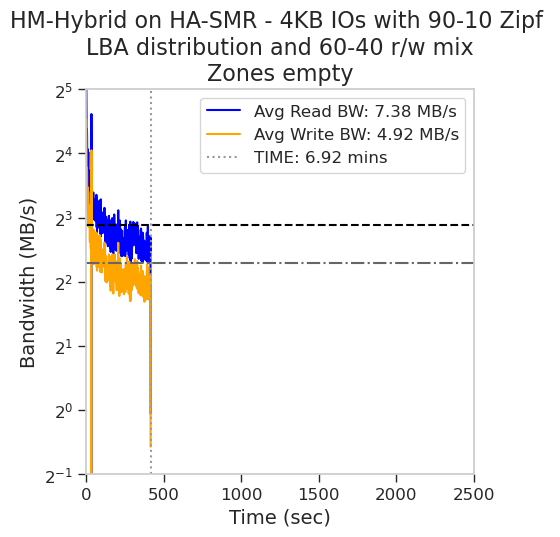

In [231]:
#Plotting
plt.figure(figsize=(5, 5))
plt.grid(False)
sns.set_theme(style="whitegrid")

ax1 = sns.lineplot(
    x='index', y='data_read_bytes', 
    data=df_hm_hasmr_empty_read_grouped_vec, 
    label='Avg Read BW: '+hm_hasmr_avg_read_bw_str, 
    color='blue'
)
ax2 = sns.lineplot(
    x='index', y='data_written_bytes', 
    data=df_hm_hasmr_empty_write_grouped_vec, 
    label='Avg Write BW: '+hm_hasmr_avg_write_bw_str, 
    color='orange'
)

ax1.set_xlabel('Time (sec)', fontsize=14)
ax1.set_ylabel('Bandwidth (MB/s)', fontsize=14)

# Add horizontal reference lines
plt.axhline(y=hm_hasmr_average_read_bandwidth, color='#000000', linestyle='--')
plt.axhline(y=hm_hasmr_average_write_bandwidth, color='#666666', linestyle='-.')
plt.axvline(x=hm_hasmr_empty_completion_time, color='#999999', linestyle=':', label='TIME: '+str(round(hm_hasmr_empty_completion_time/60,2))+' mins')

# Tick parameters with tick marks enabled
ax1.tick_params(axis='x', labelsize=12, direction='out', length=6, width=1, bottom=True, top=False)
ax1.tick_params(axis='y', labelsize=12, direction='out', length=6, width=1, left=True, right=False)

ax1.set_xlim(0, 2500)
ax1.set_xticks(ticks=np.arange(0, 2501, 500))
ax1.legend(fontsize=12)

# Log base-2 formatting
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

common_yticks = [2**i for i in range(-1, 5, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-1, 5, 2)])

lowest_power_of_2 = 2 ** -1
ax1.set_ylim(lowest_power_of_2 , 2**5)
ax1.set_yscale('log', base=2)
ax1.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))
ax1.set_title(r'HM-Hybrid on HA-SMR - 4KB IOs with 90-10 Zipf ' '\n' r'LBA distribution and 60-40 r/w mix' '\n' 'Zones empty', fontsize=16)
plt.savefig('fig/fast2026/read_write_test/hmhybrid_hasmr_4kb_90-10_empty_rw_test.pdf', dpi=300, bbox_inches='tight')
plt.show()

## HM-LS on HA-SMR - 4KB IOs with 90-10 r/w test. Zones are 90% full.

In [232]:
df_hmls = pd.read_csv('fast2026/rw_test/RWTest/4KB/90-10-LBA/HMLS/90Util/lat_log_avg_lat.1.log', names=names_latency, usecols=columns)
df_hmls_read = df_hmls[df_hmls['direction'] == 0].copy() # Read is 0 in fio logs
df_hmls_write = df_hmls[df_hmls['direction'] == 1].copy() # Write is 1 in fio logs

df_hmls_read['submission_time'] = round(df_hmls_read['submission_time'] - df_hmls_read.iloc[0].submission_time)
df_hmls_read['duration'] = df_hmls_read['duration']/1e6 #convert ns to ms
df_hmls_read['completion_time'] = df_hmls_read['submission_time'] + df_hmls_read['duration']

df_hmls_write['submission_time'] = round(df_hmls_write['submission_time'] - df_hmls_write.iloc[0].submission_time)
df_hmls_write['duration'] = df_hmls_write['duration']/1e6 #convert ns to ms
df_hmls_write['completion_time'] = df_hmls_write['submission_time'] + df_hmls_write['duration']

print(df_hmls_read.head())
print(df_hmls_write.head())

   submission_time  duration  direction  write_size  completion_time
0                0  1.419112          0        4096         1.419112
1                0  1.472971          0        4096         1.472971
2                0  1.480307          0        4096         1.480307
3                0  1.486712          0        4096         1.486712
4                0  1.496774          0        4096         1.496774
    submission_time  duration  direction  write_size  completion_time
24                0  1.718486          1        4096         1.718486
25                0  1.745873          1        4096         1.745873
26                0  1.754511          1        4096         1.754511
27                0  1.781967          1        4096         1.781967
28                0  1.782479          1        4096         1.782479


In [233]:
# Step 3: Determine time range
start_time = df_hmls_write['submission_time'].min()
end_time = math.ceil(df_hmls_write['completion_time'].max())

# Pre-compute all values vectorized
df_hmls_write_vec = df_hmls_write.copy()
df_hmls_write_vec['duration'] = df_hmls_write_vec['duration'].astype(float)
df_hmls_write_vec['start'] = df_hmls_write_vec['submission_time'].astype(int)
df_hmls_write_vec['end'] = df_hmls_write_vec['start'] + np.floor(df_hmls_write_vec['duration']).astype(int)

payload = 4096  # 4KB
df_hmls_write_vec['write_rate_per_ms'] = payload / np.maximum(df_hmls_write_vec['duration'], 1.0)
df_hmls_write_vec['floor_duration'] = np.floor(df_hmls_write_vec['duration']).astype(int)
df_hmls_write_vec['residue'] = payload - df_hmls_write_vec['write_rate_per_ms'] * df_hmls_write_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_written_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_hmls_write_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_written_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_written_array):
        data_written_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_written_ms_vec = pd.DataFrame({
    'data_written_bytes': data_written_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_written_ms_vec['data_written_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_written_ms_vec = data_written_ms_vec.loc[:last_non_zero_index]

data_written_ms_vec.reset_index(drop=True, inplace=True)

#########################################################
#Read Calculations
#########################################################
# Step 3: Determine time range
start_time = df_hmls_read['submission_time'].min()
end_time = math.ceil(df_hmls_read['completion_time'].max())

# Pre-compute all values vectorized
df_hmls_read_vec = df_hmls_read.copy()
df_hmls_read_vec['duration'] = df_hmls_read_vec['duration'].astype(float)
df_hmls_read_vec['start'] = df_hmls_read_vec['submission_time'].astype(int)
df_hmls_read_vec['end'] = df_hmls_read_vec['start'] + np.floor(df_hmls_read_vec['duration']).astype(int)

payload = 4096  # 4KB
df_hmls_read_vec['write_rate_per_ms'] = payload / np.maximum(df_hmls_read_vec['duration'], 1.0)
df_hmls_read_vec['floor_duration'] = np.floor(df_hmls_read_vec['duration']).astype(int)
df_hmls_read_vec['residue'] = payload - df_hmls_read_vec['write_rate_per_ms'] * df_hmls_read_vec['floor_duration']

# Create result array (much faster than DataFrame for this operation)
time_range = end_time - start_time + 1
data_read_array = np.zeros(time_range)

# Vectorized assignment using advanced indexing
for _, row in df_hmls_read_vec.iterrows():
    start_idx = int(row['start'] - start_time)
    end_idx = int(row['end'] - start_time)
    
    if end_idx > start_idx:
        data_read_array[start_idx:end_idx] += row['write_rate_per_ms']
    if end_idx < len(data_read_array):
        data_read_array[end_idx] += row['residue']

# Convert back to DataFrame only at the end
data_read_ms_vec = pd.DataFrame({
    'data_read_bytes': data_read_array
}, index=range(start_time, end_time + 1))

# Find last non-zero more efficiently
non_zero_mask = data_read_ms_vec['data_read_bytes'] != 0
if non_zero_mask.any():
    last_non_zero_index = non_zero_mask[::-1].idxmax()
    data_read_ms_vec = data_read_ms_vec.loc[:last_non_zero_index]

data_read_ms_vec.reset_index(drop=True, inplace=True)

In [234]:
#########################################################
#Write calculations
###########################################################
chunk_size = 10000
results = []
for i in range(0, len(data_written_ms_vec), chunk_size):
    chunk = data_written_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)

df_hmls_write_grouped_vec = pd.concat(results)

# Reset the index to make it a regular column
df_hmls_write_grouped_vec.reset_index(inplace=True)
df_hmls_write_grouped_vec['cumulative_gb'] = df_hmls_write_grouped_vec['data_written_bytes'].cumsum() / (1024 ** 3)
df_hmls_write_grouped_vec['data_written_bytes'] = df_hmls_write_grouped_vec['data_written_bytes'] / (1024 ** 2) 
#
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_hmls_write_grouped_vec.describe())
print(df_hmls_write_grouped_vec.info())
#Average write bandwidth
hmls_average_write_bandwidth = df_hmls_write_grouped_vec['data_written_bytes'].mean()
print(f"Average Write Bandwidth: {hmls_average_write_bandwidth:.2f} MB/s")
hmls_avg_write_bw_str = f"{hmls_average_write_bandwidth:.2f} MB/s"

#########################################################
#Read calculations
###########################################################
chunk_size = 10000
results = []
for i in range(0, len(data_read_ms_vec), chunk_size):
    chunk = data_read_ms_vec.iloc[i:i+chunk_size]
    result = chunk.groupby(custom_grouping).sum()
    results.append(result)
df_hmls_read_grouped_vec = pd.concat(results)
# Reset the index to make it a regular column
df_hmls_read_grouped_vec.reset_index(inplace=True)
df_hmls_read_grouped_vec['cumulative_gb'] = df_hmls_read_grouped_vec['data_read_bytes'].cumsum() / (1024 ** 3)
df_hmls_read_grouped_vec['data_read_bytes'] = df_hmls_read_grouped_vec['data_read_bytes'] / (1024 ** 2) 
#data_array = df_grouped['data_written_bytes'].values.reshape(-1, 1)
print(df_hmls_read_grouped_vec.describe())
print(df_hmls_read_grouped_vec.info())
#Average read bandwidth
hmls_average_read_bandwidth = df_hmls_read_grouped_vec['data_read_bytes'].mean()
print(f"Average Read Bandwidth: {hmls_average_read_bandwidth:.2f} MB/s")
hmls_avg_read_bw_str = f"{hmls_average_read_bandwidth:.2f} MB/s"

#Completion time -- max index in main dataframe
print(f"Write Completion time (s): {df_hmls_write_grouped_vec['index'].max()}")
print(f"Read Completion time (s): {df_hmls_read_grouped_vec['index'].max()}")
hmls_completion_time = max(df_hmls_write_grouped_vec['index'].max(), df_hmls_read_grouped_vec['index'].max())
print(f"Overall Completion time (mins): {hmls_completion_time/60}")


            index  data_written_bytes  cumulative_gb
count  620.000000          620.000000     620.000000
mean   309.500000            3.304165       1.107729
std    179.122863            2.521614       0.550591
min      0.000000            0.000000       0.018722
25%    154.750000            0.421082       0.661733
50%    309.500000            3.883948       1.130218
75%    464.250000            4.654121       1.575425
max    619.000000           19.171741       2.000568
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 620 entries, 0 to 619
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               620 non-null    int64  
 1   data_written_bytes  620 non-null    float64
 2   cumulative_gb       620 non-null    float64
dtypes: float64(2), int64(1)
memory usage: 14.7 KB
None
Average Write Bandwidth: 3.30 MB/s
            index  data_read_bytes  cumulative_gb
count  619.000000       619.00000

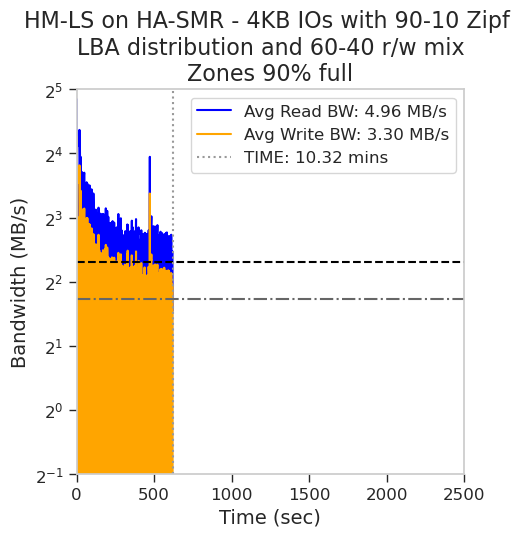

In [235]:
#Plotting
plt.figure(figsize=(5, 5))
plt.grid(False)
sns.set_theme(style="whitegrid")

ax1 = sns.lineplot(
    x='index', y='data_read_bytes', 
    data=df_hmls_read_grouped_vec, 
    label='Avg Read BW: '+hmls_avg_read_bw_str, 
    color='blue'
)
ax2 = sns.lineplot(
    x='index', y='data_written_bytes', 
    data=df_hmls_write_grouped_vec, 
    label='Avg Write BW: '+hmls_avg_write_bw_str, 
    color='orange'
)

ax1.set_xlabel('Time (sec)', fontsize=14)
ax1.set_ylabel('Bandwidth (MB/s)', fontsize=14)

# Add horizontal reference lines
plt.axhline(y=hmls_average_read_bandwidth, color='#000000', linestyle='--')
plt.axhline(y=hmls_average_write_bandwidth, color='#666666', linestyle='-.')
plt.axvline(x=hmls_completion_time, color='#999999', linestyle=':', label='TIME: '+str(round(hmls_completion_time/60,2))+' mins')

# Tick parameters with tick marks enabled
ax1.tick_params(axis='x', labelsize=12, direction='out', length=6, width=1, bottom=True, top=False)
ax1.tick_params(axis='y', labelsize=12, direction='out', length=6, width=1, left=True, right=False)

ax1.set_xlim(0, 2500)
ax1.set_xticks(ticks=np.arange(0, 2501, 500))
ax1.legend(fontsize=12)

# Log base-2 formatting
def log2_format(y, pos):
    return f'$2^{{{int(np.log2(y))}}}$' if y > 0 else '0'

common_yticks = [2**i for i in range(-1, 5, 2)]
plt.yticks(common_yticks, [str(2**i) for i in range(-1, 5, 2)])

lowest_power_of_2 = 2 ** -1
ax1.set_ylim(lowest_power_of_2 , 2**5)
ax1.set_yscale('log', base=2)
ax1.get_yaxis().set_major_formatter(ticker.FuncFormatter(log2_format))

ax1.set_title(r'HM-LS on HA-SMR - 4KB IOs with 90-10 Zipf ' '\n' r'LBA distribution and 60-40 r/w mix' '\n' 'Zones 90% full', fontsize=16)

plt.savefig('fig/fast2026/read_write_test/hm_ls_hasmr_4kb_90-10_90full_rw_test.pdf', dpi=300, bbox_inches='tight')
plt.show()


## HM-LS on HA-SMR - 4KB IOs with 90-10 r/w test. Zones are empty.

## NO TEST WITH HM-LS ON EMPTY ZONES.